In [45]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml

X,y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [46]:
X = X.to_numpy().astype(int) / 255
y = y.to_numpy().astype(int)

In [47]:
y = y.reshape(-1, 1)

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(784, )))
model.add(Dense(96, activation='relu'))
model.add(Dense(10, activation='softmax'))

/Users/aryanahuja/Documents/Aryan/Projects/DL_Prac/env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
model.compile(
    optimizer='adam',
    metrics=['accuracy'],
    loss='sparse_categorical_crossentropy'
)

In [65]:
history = model.fit(X_train, y_train, epochs=10, validation_data=[X_test, y_test])

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - accuracy: 0.9948 - loss: 0.0163 - val_accuracy: 0.9754 - val_loss: 0.1108
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9940 - loss: 0.0178 - val_accuracy: 0.9769 - val_loss: 0.1042
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9771 - val_loss: 0.1125
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9783 - val_loss: 0.1035
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.9737 - val_loss: 0.1367
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 933us/step - accuracy: 0.9957 - loss: 0.0135 - val_accuracy: 0.9755 - val_loss: 0.1321
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9959 - loss: 0.0131 - val_accuracy: 0.9771 - val_loss: 0.1258
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9968 - loss: 0.009

In [66]:
model.evaluate(X_test, y_test)

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - accuracy: 0.9776 - loss: 0.1336


[0.1336410939693451, 0.977571427822113]

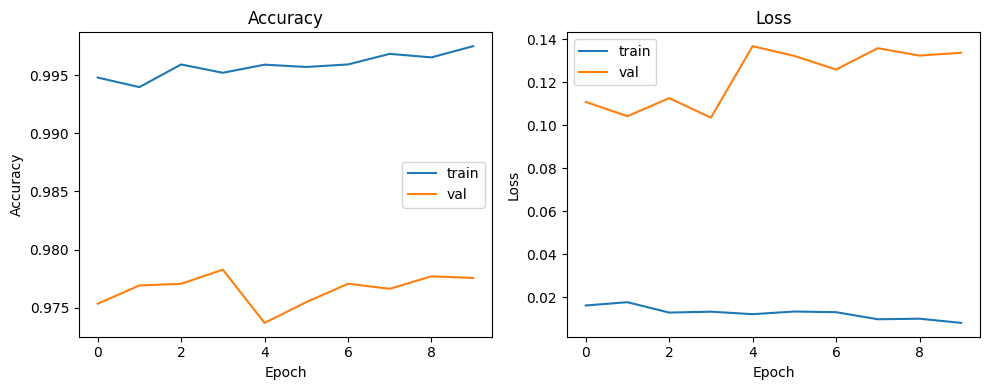

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()